# Analyze spatial biological findings

**Aim.** Recover and interpret a tertiary lymphoid structure (TLS)-like immune niche in a renal cell carcinoma ST section.

**Outputs.** Reference-guided gene-expression maps, TLS localization metrics, spot-level molecular evidence and a cross-study summary of 12 spatial biological findings.

## Installation

Create a Python 3.10+ environment, install the public HistAgent package and add
the lightweight analysis dependencies used by these notebooks.

```bash
git clone https://github.com/zipging/HistAgent.git
cd HistAgent
python -m venv .venv
source .venv/bin/activate
python -m pip install -e .
python -m pip install jupyter numpy pandas matplotlib seaborn scipy scikit-learn torch huggingface-hub
```

If `data/` is absent, the notebook downloads its data from
`wli13/HistAgent-data`. These examples run without a GPU. Running HistAgent on
new images requires access to the gated Prov-GigaPath model and an authenticated
Hugging Face session.

## Setup

Import the analysis packages, locate the tutorial data and set the plotting style.

In [1]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

configured_data = os.getenv("HISTAGENT_TUTORIAL_DATA", "").strip()
DATA_DIR = Path(configured_data).expanduser() if configured_data else Path("data")
if not DATA_DIR.exists():
    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=["tutorials/**", "manifest.json"],
        )
    )
    DATA_DIR = snapshot / "tutorials"
assert DATA_DIR.exists(), f"Tutorial data not found: {DATA_DIR}"

def rankridge_pack_root(groups):
    configured = os.getenv("HISTAGENT_RANKRIDGE_PACKS", "").strip()
    if configured:
        root = Path(configured).expanduser()
        if not (root / groups[0]).exists():
            root = root / "rankridge_tutorial_packs"
        assert (root / groups[0]).exists(), f"RankRidge pack not found: {root}"
        return root

    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=[
                f"rankridge_tutorial_packs/{group}/**" for group in groups
            ],
        )
    )
    return snapshot / "rankridge_tutorial_packs"

sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.dpi": 115,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#000000",
    "axes.labelcolor": "#000000",
    "axes.linewidth": 1.25,
    "axes.grid": False,
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "text.color": "#000000",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
})
COLORS = {
    "HistAgent": "#168267",
    "Measured ST": "#6f7477",
    "STPath": "#cb77a0",
    "OmiCLIP": "#69aec7",
}
SURVIVAL_COLORS = {"High risk": "#ef4545", "Low risk": "#45b3c2"}
REGION_COLORS = {
    "Poor": "#d85f6b",
    "High": "#79a9d1",
    "Negative": "#b7b7b7",
    "Tumor": "#e32925",
    "Stroma": "#62acec",
}
TASK_CMAPS = {
    "svg": "YlGnBu",
    "domain": "tab10",
    "deconv": "Greens",
    "deg": "Purples",
    "pathway": "PuBuGn",
}

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 37 files:   0%|          | 0/37 [00:00<?, ?it/s]

## Overview

The example is renal cell carcinoma section GSE175540_GSM5924038. Compare reference-guided HistAgent expression estimates with measured ST, localize a tertiary lymphoid structure (TLS)-like niche and inspect its molecular profile.

In [2]:
from scipy.stats import pearsonr, mannwhitneyu
from sklearn.metrics import average_precision_score
from IPython.display import HTML, display

coordinates = pd.read_json(DATA_DIR / "fig2b_spots.json")[
    ["barcode", "x", "y"]
]
measured_expression = pd.read_csv(
    DATA_DIR / "figure2b_measured_expression.csv"
)
tls_spots = pd.read_json(DATA_DIR / "fig2c_spots.json")
tls_metrics = pd.read_json(DATA_DIR / "fig2c_metrics.json")
findings = pd.read_json(DATA_DIR / "fig2e.json")
tls_example = json.loads((DATA_DIR / "tls_worked_example.json").read_text())

## Reference-guided expression estimates

Fit the paper's post hoc ridge mapper on the compact kidney reference matrices, then apply it to the RCC rank-feature matrix. The query slide's measured expression is used only for the comparison after inference.

All eight genes are drawn from their spot coordinates. Four genes share each row, and every measured/predicted pair uses the same within-gene color scale. PCC is recalculated directly from the values produced below.

In [3]:
from scipy import sparse

PACK_DIR = rankridge_pack_root(["rcc__human_kidney"])
pack = PACK_DIR / "rcc__human_kidney"
pack_info = json.loads((pack / "pack_manifest.json").read_text())

x_reference = sparse.load_npz(
    pack / "reference_rank_features.npz"
).astype(np.float32)
y_reference = sparse.load_npz(
    pack / "reference_expression_targets.npz"
).astype(np.float32)

gram = (x_reference.T @ x_reference).toarray().astype(np.float64)
gram.flat[:: gram.shape[0] + 1] += pack_info["alpha"]
cross_product = (x_reference.T @ y_reference).toarray().astype(np.float64)
coefficients = np.linalg.solve(gram, cross_product)

stored_coefficients = np.load(pack / "ridge_coefficients.npy")
assert np.allclose(coefficients, stored_coefficients, atol=2e-5)

x_query = sparse.load_npz(pack / "query_rank_features.npz")
predicted_expression = np.asarray(x_query @ coefficients)
target_genes = (pack / "target_genes.txt").read_text().splitlines()
query_rows = pd.read_csv(pack / "query_rows.csv")

gene_spots = query_rows[["barcode"]].copy()
for index, gene in enumerate(target_genes):
    gene_spots[f"HistAgent_{gene}"] = predicted_expression[:, index]
gene_spots = gene_spots.merge(
    measured_expression, on="barcode", validate="one_to_one"
).merge(
    coordinates, on="barcode", validate="one_to_one"
)

genes_to_plot = [
    "IGHG2", "IGHG4", "IGLV3-1", "C7",
    "COL1A1", "DCN", "FN1", "TGFBI",
]
recalculated = []
for gene in genes_to_plot:
    measured = np.log1p(gene_spots[f"ST_{gene}"].clip(lower=0))
    predicted = np.log1p(
        gene_spots[f"HistAgent_{gene}"].clip(lower=0)
    )
    recalculated.append({
        "Gene": gene,
        "PCC": pearsonr(measured, predicted).statistic,
    })

gene_pcc = pd.DataFrame(recalculated)
print(
    f"Reference spots: {x_reference.shape[0]:,} · "
    f"rank features: {x_reference.shape[1]:,} · "
    f"mean PCC: {gene_pcc['PCC'].mean():.3f}"
)
gene_pcc.round(3).style.set_properties(
    subset=["Gene"], **{"font-style": "italic"}
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Reference spots: 42,273 · rank features: 1,000 · mean PCC: 0.576


,Gene,PCC
0,IGHG2,0.491000
1,IGHG4,0.498000
2,IGLV3-1,0.509000
3,C7,0.645000
4,COL1A1,0.572000
5,DCN,0.613000
6,FN1,0.669000
7,TGFBI,0.611000


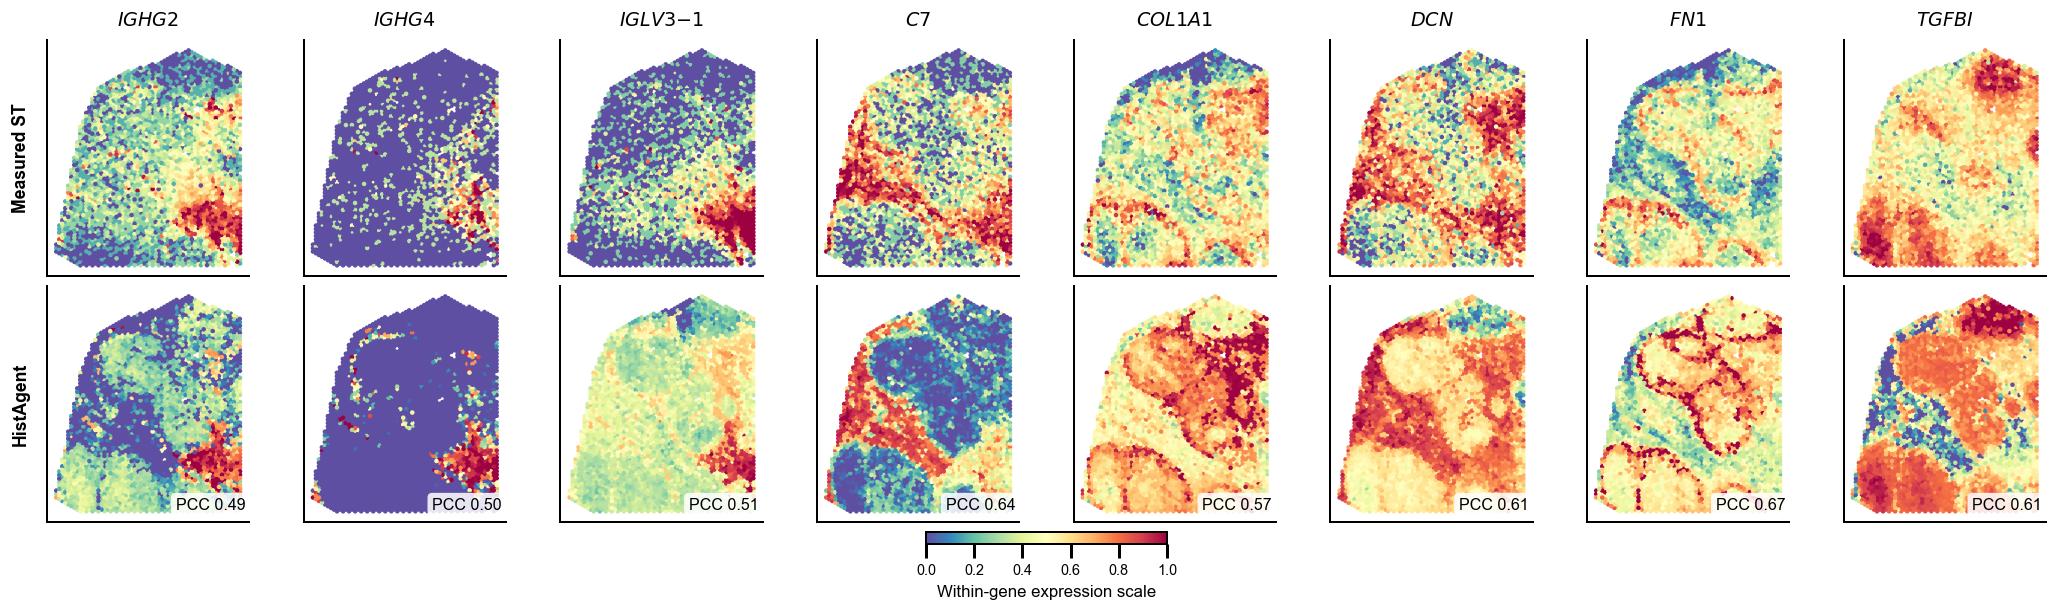

In [4]:
fig, axes = plt.subplots(
    2, len(genes_to_plot), figsize=(18, 5.2), constrained_layout=True
)

for col, gene in enumerate(genes_to_plot):
    measured = np.log1p(gene_spots[f"ST_{gene}"].to_numpy(float))
    predicted = np.log1p(
        gene_spots[f"HistAgent_{gene}"].clip(lower=0).to_numpy(float)
    )
    r = pearsonr(measured, predicted).statistic
    lo, hi = np.nanpercentile(np.r_[measured, predicted], [2, 98])
    scale = max(hi - lo, np.finfo(float).eps)

    for row, (label, values) in enumerate([
        ("Measured ST", measured), ("HistAgent", predicted)
    ]):
        ax = axes[row, col]
        normalized = np.clip((values - lo) / scale, 0, 1)
        sc = ax.scatter(
            gene_spots["x"], gene_spots["y"], c=normalized, s=8,
            cmap="Spectral_r", vmin=0, vmax=1, linewidths=0
        )
        ax.set_aspect("equal")
        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            gene_label = gene.replace("-", r"{-}")
            ax.set_title(
                rf"$\mathit{{{gene_label}}}$", pad=9, fontweight="bold"
            )
        else:
            ax.text(
                .98, .04, f"PCC {r:.2f}", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=10,
                bbox={"boxstyle": "round,pad=.3", "fc": "white", "ec": "none",
                      "alpha": .86},
            )
        if col == 0:
            ax.set_ylabel(label, fontsize=11, fontweight="bold", labelpad=11)

fig.colorbar(
    sc, ax=axes, orientation="horizontal", fraction=.025, pad=.02,
    label="Within-gene expression scale"
)

plt.show()

## TLS localization

The TLS score is evaluated against the published spot labels. AUPRC is used because TLS spots are the minority class.

In [5]:
score_cols = {"HistAgent": "HistAgent_score", "Measured ST": "Measured_ST_score"}
rows = []
for method, column in score_cols.items():
    y = tls_spots["y_true"].astype(int).to_numpy()
    score = tls_spots[column].to_numpy(float)
    rows.append({
        "method": method,
        "AUPRC": average_precision_score(y, score),
    })
pd.DataFrame(rows).rename(columns={"method": "Method"})[
    ["Method", "AUPRC"]
].round(3)

,Method,AUPRC
0,HistAgent,0.586
1,Measured ST,0.592


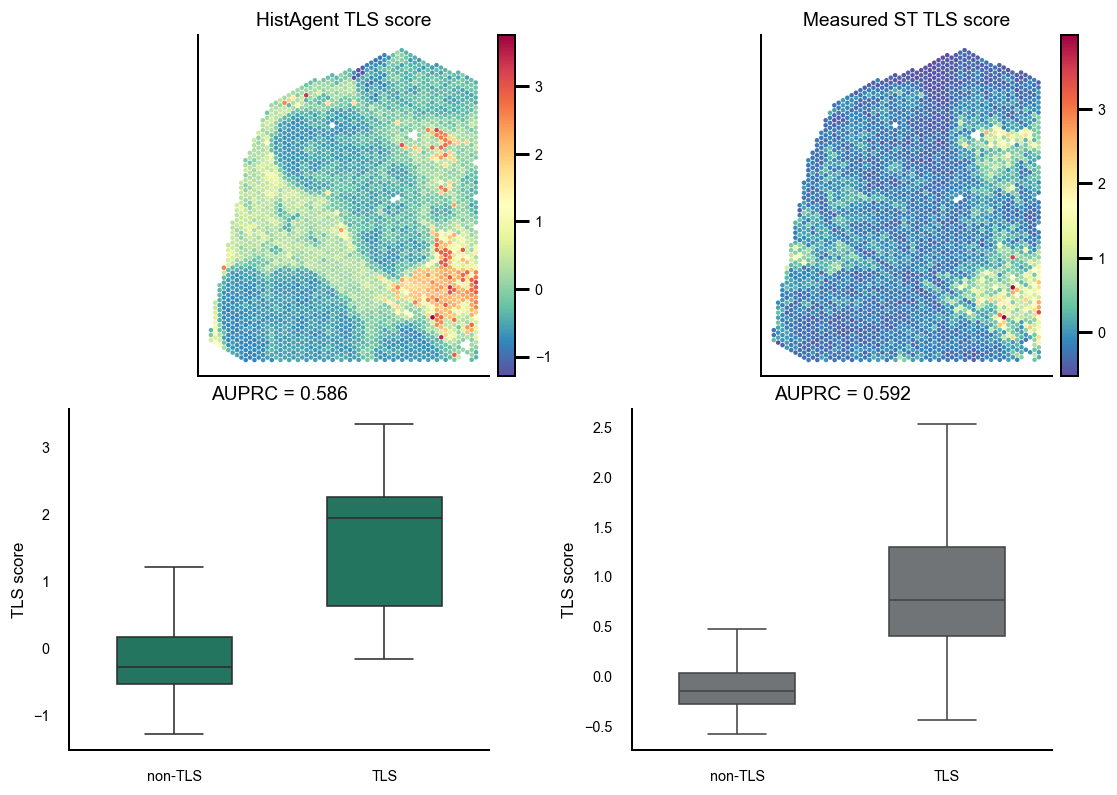

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(9.6, 6.8), constrained_layout=True)
y = tls_spots["y_true"].astype(int).to_numpy()

for col, (method, score_col) in enumerate(score_cols.items()):
    score = tls_spots[score_col].to_numpy(float)
    sc = axes[0, col].scatter(tls_spots["x"], tls_spots["y"], c=score, s=8,
                              cmap="Spectral_r", linewidths=0)
    axes[0, col].set_title(f"{method} TLS score")
    axes[0, col].set_aspect("equal")
    axes[0, col].invert_yaxis()
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])
    fig.colorbar(sc, ax=axes[0, col], fraction=0.045, pad=0.02)

    plot_df = pd.DataFrame({
        "annotation": np.where(y == 1, "TLS", "non-TLS"),
        "score": score,
    })
    sns.boxplot(data=plot_df, x="annotation", y="score", ax=axes[1, col],
                color=COLORS[method], width=0.55, showfliers=False)
    axes[1, col].set_title(
        f"AUPRC = {average_precision_score(y, score):.3f}"
    )
    axes[1, col].set_xlabel("")
    axes[1, col].set_ylabel("TLS score")

plt.show()

## TLS molecular profile at a measured spot

The source study labels this spot as TLS. Its ranked molecular profile combines immunoglobulin, antigen-presentation and stromal-matrix signals.

In [7]:
tls_markers = {
    "B and plasma cell": {
        "IGKC", "IGLC1", "IGHG1", "IGHG2", "IGHG3", "IGHG4",
        "IGHA1", "JCHAIN", "IGLV3-1", "IGKV4-1"
    },
    "Antigen presentation": {"B2M", "CD74", "HLA-DRA", "HLA-E"},
    "Stromal matrix": {
        "COL1A1", "COL1A2", "COL3A1", "FN1", "SPARC", "LUM",
        "DCN", "C7", "VCAN", "C1R", "C3"
    },
}
pred50 = tls_example["predicted_top50"]
matched = {
    group: [gene for gene in pred50 if gene in markers]
    for group, markers in tls_markers.items()
}
def italic_gene_list(genes):
    return ", ".join(f"<i>{gene}</i>" for gene in genes)

card = f'''
<div style="border:1px solid #d8d1c6;border-radius:16px;padding:22px;background:#fffdf8">
  <div style="font:600 12px/1.2 sans-serif;letter-spacing:.08em;color:#9b4c34">WORKED TLS SPOT</div>
  <h3 style="margin:.4rem 0">{tls_example['barcode'].split('_')[-1]}</h3>
  <p>Measured label: <b>{tls_example['measured_annotation']}</b></p>
  <p><b>B and plasma cell:</b> {italic_gene_list(matched['B and plasma cell'])}</p>
  <p><b>Antigen presentation:</b> {italic_gene_list(matched['Antigen presentation'])}</p>
  <p><b>Stromal matrix:</b> {italic_gene_list(matched['Stromal matrix'])}</p>
  <p style="color:#5b5a56;margin-bottom:0">The profile recovers a plasma-cell-rich immune program together with the surrounding stromal matrix.</p>
</div>
'''
display(HTML(card))

## Cross-study biological finding recovery

The comparison covers the 12 literature-defined biological findings reported in the paper, evaluated across 29 slide-finding pairs from 22 unique slides. Each bar reports the mean AUPRC across the evaluated slides for one target.

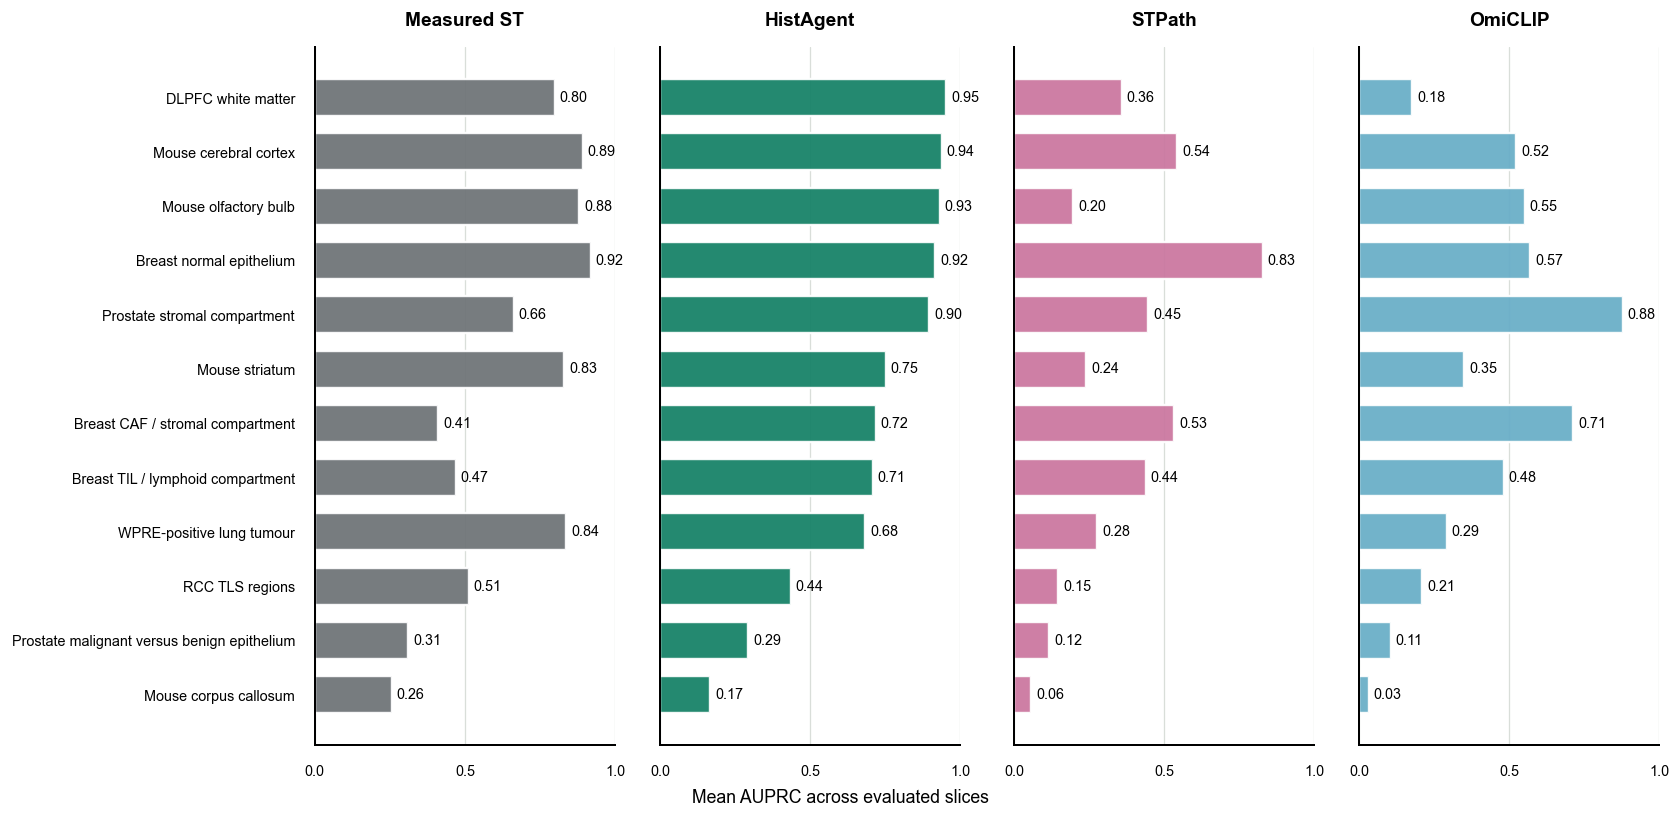

In [8]:
method_cols = ["HistAgent AUPRC", "Measured ST AUPRC",
               "STPath AUPRC", "OmiCLIP AUPRC"]
target_mean = (
    findings.groupby(
        ["Biological category", "Biological target"], sort=False
    )[method_cols]
    .mean()
    .reset_index()
)
order = (
    target_mean.sort_values("HistAgent AUPRC")["Biological target"].tolist()
)
ordered = target_mean.set_index("Biological target").loc[order].reset_index()
method_panels = [
    ("Measured ST", "Measured ST AUPRC"),
    ("HistAgent", "HistAgent AUPRC"),
    ("STPath", "STPath AUPRC"),
    ("OmiCLIP", "OmiCLIP AUPRC"),
]

fig, axes = plt.subplots(
    1, 4, figsize=(14.5, 7), sharey=True,
    gridspec_kw={"wspace": .06}, constrained_layout=True
)
for ax, (method, column) in zip(axes, method_panels):
    values = ordered[column].to_numpy()
    bars = ax.barh(
        np.arange(len(ordered)), values, height=.68,
        color=COLORS[method], alpha=.94
    )
    ax.set_title(method, fontweight="bold", pad=14)
    ax.set_xlim(0, 1)
    ax.set_xticks([0, .5, 1])
    ax.grid(axis="x", color="#d9ded9", linewidth=.8)
    ax.grid(axis="y", visible=False)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    if ax is axes[0]:
        ax.set_yticks(
            np.arange(len(ordered)),
            ordered["Biological target"].str.replace("_", " ", regex=False),
        )
        ax.tick_params(axis="y", labelsize=9)
    else:
        ax.tick_params(axis="y", left=False)

fig.supxlabel("Mean AUPRC across evaluated slices", fontsize=11)
plt.show()

## Verify the calculations

In [9]:
reported = tls_metrics.set_index("method")["auprc"]
for row in rows:
    assert np.isclose(row["AUPRC"], reported[row["method"]])

direct_pcc = gene_pcc.set_index("Gene")["PCC"].to_dict()
saved_pcc = pd.read_json(
    DATA_DIR / "fig2b_pcc.json"
).set_index("gene")["pcc"].to_dict()
for gene in genes_to_plot:
    assert np.isclose(direct_pcc[gene], saved_pcc[gene], atol=1e-6)

assert findings["Biological target"].nunique() == 12
assert len(findings) == 29
assert findings["Section"].nunique() == 22
print("Checks passed for expression PCC, TLS AUPRC and all 29 slide-finding pairs.")

Checks passed for expression PCC, TLS AUPRC and all 29 slide-finding pairs.


## Continue

Continue to **Spatial transcriptomic analyses** to test whether recovered molecular readouts recapitulate five standard ST analyses across 135 held-out slides.